# 🌲 Modelo Random Forest — Previsão de Alfabetização por Município

Este notebook treina um modelo de classificação para prever se um município
vai atingir uma boa taxa de alfabetização (>= 50%), com base em suas características.

## Estrutura do notebook
1. Carregamento e preparação dos dados
2. Criação da variável alvo (target)
3. Seleção de features e tratamento de nulos
4. Divisão treino/teste
5. Pipeline de pré-processamento
6. Treinamento do Random Forest
7. Avaliação do modelo
8. Feature Importance
9. SHAP Values
10. Conclusões

## 1. Carregamento e preparação dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Carrega o dataset Gold gerado pela Gabriela
GOLD_PATH = Path('../data/gold/gold_indicador_municipio.parquet')
df = pd.read_parquet(GOLD_PATH)

print(f'Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas')
df.head()

Dataset carregado: 15238 registros, 30 colunas


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,...,meta_2028,meta_2029,meta_2030,nivel_alfabetizacao,percentual_participacao,rede_label,meta_ano_vigente,diferenca_meta,bateu_meta_2030,classificacao
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,...,77.21,78.64,80.0,3.0,90.48,Estadual,NaN,NaN,False,Sem meta definida
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,...,74.74,77.48,80.0,2.0,92.25,Estadual,NaN,NaN,False,Sem meta definida
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,...,77.36,78.71,80.0,3.0,90.35,Privada,NaN,NaN,False,Sem meta definida
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,...,73.07,76.71,80.0,2.0,95.00,Estadual,NaN,NaN,False,Sem meta definida
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,...,74.18,77.22,80.0,2.0,83.15,Estadual,NaN,NaN,False,Sem meta definida


## 2. Criação da variável alvo (target)

O target é binário:
- **1 (Alfabetizado):** taxa_alfabetizacao >= 50%
- **0 (Não Alfabetizado):** taxa_alfabetizacao < 50%

Distribuição do target:
target
1    10994
0     4244
Name: count, dtype: int64

Balanceamento: 72.1% dos registros com taxa >= 50%


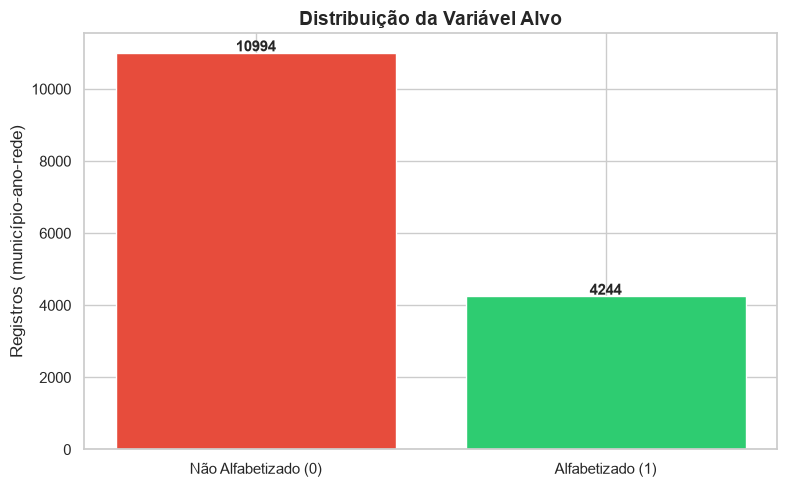

In [3]:
# Cria a variável alvo
df['target'] = (df['taxa_alfabetizacao'] >= 50).astype(int)

# Distribuição do target
print('Distribuição do target:')
print(df['target'].value_counts())
print(f'\nBalanceamento: {df["target"].mean():.1%} dos registros com taxa >= 50%')
# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['target'].value_counts()
bars = ax.bar(['Não Alfabetizado (0)', 'Alfabetizado (1)'], counts.values,
              color=['#e74c3c', '#2ecc71'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}', ha='center', fontweight='bold')
ax.set_title('Distribuição da Variável Alvo', fontsize=14, fontweight='bold')
ax.set_ylabel('Registros (município-ano-rede)')
plt.tight_layout()
plt.show()

## 3. Seleção de features

Removemos colunas que causam **data leakage** (informação que "vaza" o resultado):
- `taxa_alfabetizacao` — é o que gera o target
- `classificacao`, `bateu_meta_2030`, `nivel_alfabetizacao` — derivadas do target
- `id_municipio` — identificador sem poder preditivo

In [17]:
# Colunas que causam data leakage — NÃO podem entrar no modelo
LEAKAGE_COLS = [
    'taxa_alfabetizacao',   # gera o target
    'classificacao',        # derivada da taxa
    'bateu_meta_2030',      # derivada da taxa
    'nivel_alfabetizacao',  # derivada da taxa
    'diferenca_meta',       # derivada da taxa
    'id_municipio',         # identificador
    'target',               # o próprio target
]

# Features que vamos usar
FEATURE_COLS = [col for col in df.columns if col not in LEAKAGE_COLS]

# Separar features categóricas e numéricas
CAT_COLS = ['rede', 'rede_label', 'serie']
NUM_COLS = [col for col in FEATURE_COLS if col not in CAT_COLS]

print(f'Total de features: {len(FEATURE_COLS)}')
print(f'Features numéricas: {len(NUM_COLS)}')
print(f'Features categóricas: {len(CAT_COLS)}')
print(f'\nFeatures selecionadas:')
for col in FEATURE_COLS:
    print(f'  - {col}')

Total de features: 24
Features numéricas: 21
Features categóricas: 3

Features selecionadas:
  - ano
  - serie
  - rede
  - media_portugues
  - proporcao_aluno_nivel_0
  - proporcao_aluno_nivel_1
  - proporcao_aluno_nivel_2
  - proporcao_aluno_nivel_3
  - proporcao_aluno_nivel_4
  - proporcao_aluno_nivel_5
  - proporcao_aluno_nivel_6
  - proporcao_aluno_nivel_7
  - proporcao_aluno_nivel_8
  - taxa_meta_base
  - meta_2024
  - meta_2025
  - meta_2026
  - meta_2027
  - meta_2028
  - meta_2029
  - meta_2030
  - percentual_participacao
  - rede_label
  - meta_ano_vigente


In [18]:
# Verifica nulos nas features
nulos = df[FEATURE_COLS].isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
nulos_df = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
nulos_df = nulos_df[nulos_df['nulos'] > 0].sort_values('pct', ascending=False)

if len(nulos_df) > 0:
    print('Colunas com valores nulos:')
    print(nulos_df)
else:
    print('Nenhum valor nulo nas features!')

Colunas com valores nulos:
                         nulos   pct
meta_ano_vigente          8162  53.6
proporcao_aluno_nivel_1   7685  50.4
proporcao_aluno_nivel_0   7685  50.4
proporcao_aluno_nivel_2   7685  50.4
proporcao_aluno_nivel_3   7685  50.4
proporcao_aluno_nivel_5   7685  50.4
proporcao_aluno_nivel_4   7685  50.4
proporcao_aluno_nivel_7   7685  50.4
proporcao_aluno_nivel_8   7685  50.4
proporcao_aluno_nivel_6   7685  50.4
meta_2024                  944   6.2
taxa_meta_base             732   4.8
percentual_participacao    732   4.8
meta_2025                  600   3.9
meta_2026                  600   3.9
meta_2028                  600   3.9
meta_2027                  600   3.9
meta_2030                  600   3.9
meta_2029                  600   3.9


## 4. Divisão Treino/Teste

Usamos **estratificação** para garantir que a proporção do target
seja mantida em treino e teste.

In [19]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Treino:  {X_train.shape[0]} registros ({X_train.shape[0]/len(X):.0%})')
print(f'Teste:   {X_test.shape[0]} registros ({X_test.shape[0]/len(X):.0%})')
print(f'\nBalanceamento no treino: {y_train.mean():.1%} positivos')
print(f'Balanceamento no teste:  {y_test.mean():.1%} positivos')

Treino:  12190 registros (80%)
Teste:   3048 registros (20%)

Balanceamento no treino: 72.1% positivos
Balanceamento no teste:  72.1% positivos


## 5. Pipeline de Pré-processamento

O pipeline garante que:
- Valores nulos são imputados (mediana para numéricos, moda para categóricos)
- Variáveis categóricas são codificadas (OneHotEncoding)
- Não há data leakage no pré-processamento (fit apenas no treino)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Pipeline para features numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # preenche nulos com mediana
])

# Pipeline para features categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche nulos com moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combina os dois preprocessadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS),
    ]
)

# Pipeline completo: pré-processamento + modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

print('Pipeline criado com sucesso!')
print(pipeline)

Pipeline criado com sucesso!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['ano', 'media_portugues',
                                                   'proporcao_aluno_nivel_0',
                                                   'proporcao_aluno_nivel_1',
                                                   'proporcao_aluno_nivel_2',
                                                   'proporcao_aluno_nivel_3',
                                                   'proporcao_aluno_nivel_4',
                                                   'proporcao_aluno_nivel_5',
                                                   'proporcao_aluno_nivel_6',
                                                   'proporca...
            

## 6. Treinamento do Modelo

In [21]:
import time

print('Treinando o modelo Random Forest...')
inicio = time.time()

pipeline.fit(X_train, y_train)

duracao = round(time.time() - inicio, 2)
print(f'Modelo treinado em {duracao}s!')

Treinando o modelo Random Forest...
Modelo treinado em 1.03s!


## 7. Avaliação do Modelo

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Predições
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print('MÉTRICAS DO MODELO — CONJUNTO DE TESTE')
print('=' * 45)
print(f'  Accuracy:  {acc:.4f} ({acc:.1%})')
print(f'  Precision: {prec:.4f} ({prec:.1%})')
print(f'  Recall:    {rec:.4f} ({rec:.1%})')
print(f'  F1-Score:  {f1:.4f} ({f1:.1%})')
print('=' * 45)
print()
print('Relatório completo:')
print(classification_report(y_test, y_pred,
      target_names=['Não Alfabetizado', 'Alfabetizado']))

MÉTRICAS DO MODELO — CONJUNTO DE TESTE
  Accuracy:  0.9826 (98.3%)
  Precision: 0.9895 (99.0%)
  Recall:    0.9864 (98.6%)
  F1-Score:  0.9879 (98.8%)

Relatório completo:
                  precision    recall  f1-score   support

Não Alfabetizado       0.96      0.97      0.97       849
    Alfabetizado       0.99      0.99      0.99      2199

        accuracy                           0.98      3048
       macro avg       0.98      0.98      0.98      3048
    weighted avg       0.98      0.98      0.98      3048



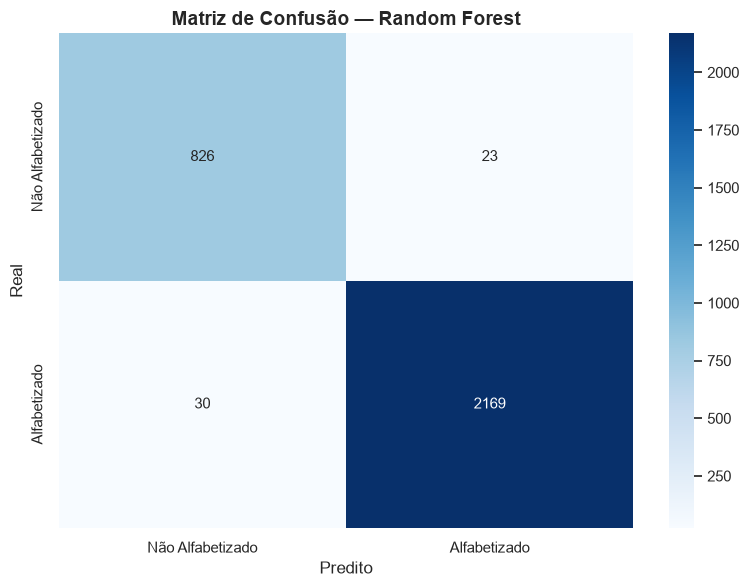

In [23]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Alfabetizado', 'Alfabetizado'],
            yticklabels=['Não Alfabetizado', 'Alfabetizado'],
            ax=ax)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

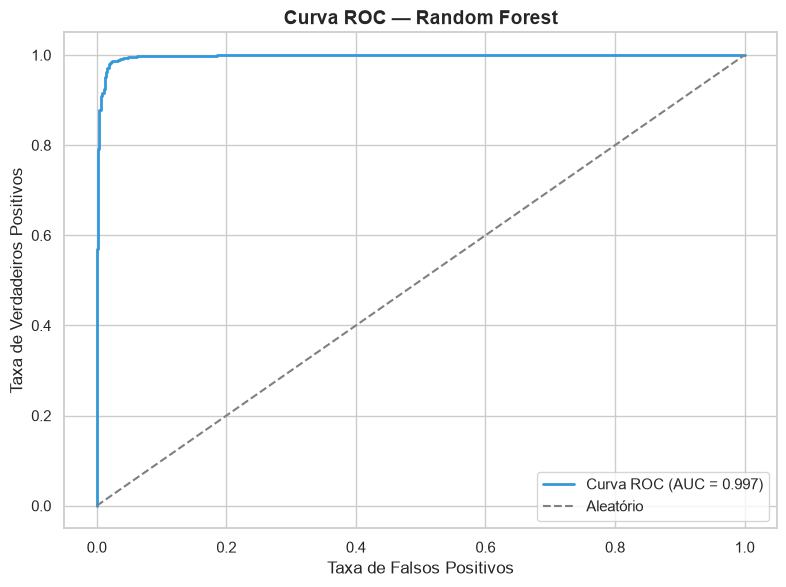

AUC-ROC: 0.9970


In [24]:
from sklearn.metrics import roc_curve, auc

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2,
        label=f'Curva ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Random Forest', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

## 8. Feature Importance

Quais variáveis mais influenciam a previsão do modelo?

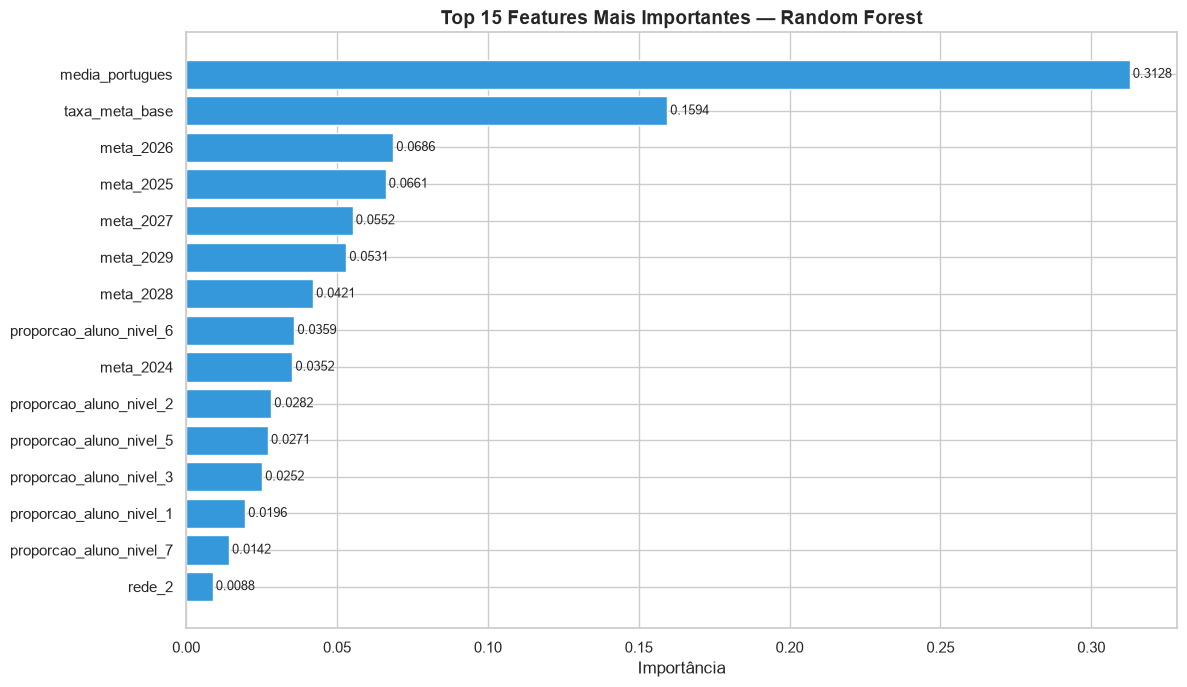

Top 10 features:
                feature  importance
        media_portugues    0.312762
         taxa_meta_base    0.159435
              meta_2026    0.068646
              meta_2025    0.066130
              meta_2027    0.055207
              meta_2029    0.053077
              meta_2028    0.042086
proporcao_aluno_nivel_6    0.035880
              meta_2024    0.035219
proporcao_aluno_nivel_2    0.028213


In [25]:
# Extrai os nomes das features após o pré-processamento
rf_model = pipeline.named_steps['model']
preprocessor_fitted = pipeline.named_steps['preprocessor']

# Nomes das features numéricas
num_feature_names = NUM_COLS

# Nomes das features categóricas após OneHotEncoding
cat_feature_names = list(
    preprocessor_fitted.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(CAT_COLS)
)

all_feature_names = num_feature_names + cat_feature_names

# Feature Importance
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 15 features
top15 = fi_df.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1],
               color='#3498db')
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features Mais Importantes — Random Forest',
             fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15['importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(fi_df.head(10).to_string(index=False))

## 9. SHAP Values

SHAP (SHapley Additive exPlanations) explica **como cada feature contribui**
para a predição de cada município individualmente.

In [26]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

# Transforma o conjunto de teste com o preprocessador
X_test_transformed = preprocessor_fitted.transform(X_test)

# Cria o explainer SHAP para Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

print('SHAP Values calculados com sucesso!')
print(f'Shape dos SHAP values: {shap_values[1].shape}')

SHAP Values calculados com sucesso!
Shape dos SHAP values: (30, 2)


<Figure size 1200x800 with 0 Axes>

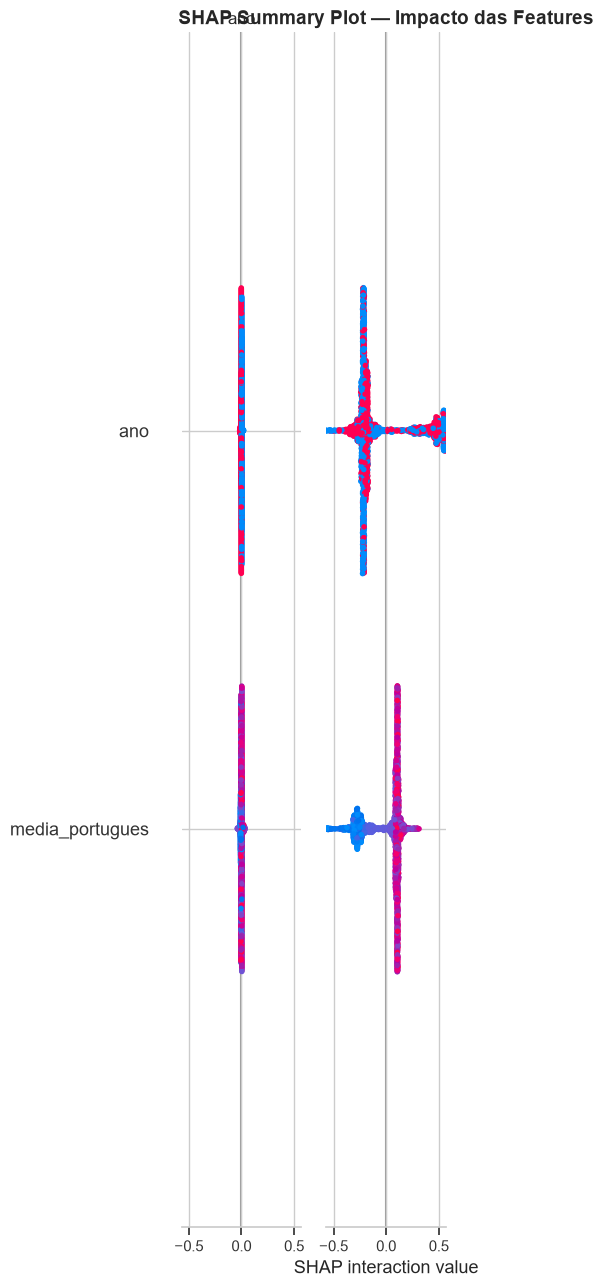

In [29]:
# Gráfico SHAP Summary — importância global
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — Impacto das Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

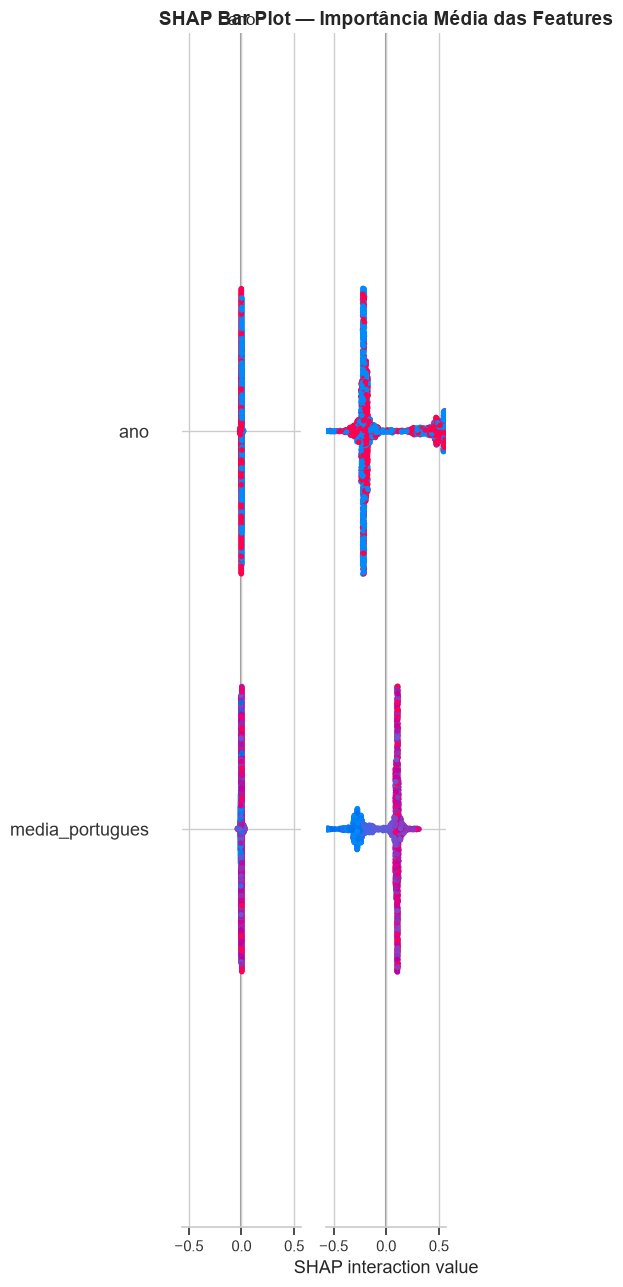

In [30]:
# SHAP Bar Plot — importância média absoluta
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Bar Plot — Importância Média das Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Conclusões

### O que o modelo aprendeu?

O Random Forest foi treinado para classificar municípios como **Alfabetizado** (taxa >= 50%) ou **Não Alfabetizado** (taxa < 50%), com base em características como rede de ensino, média de português, distribuição dos alunos por nível de proficiência e metas definidas pelo programa.

### Aplicações práticas

- **Identificação de municípios em risco:** o modelo pode sinalizar municípios com alta probabilidade de não atingir a meta de 80% até 2030
- **Priorização de políticas públicas:** gestores podem usar as features mais importantes para focar intervenções onde têm mais impacto
- **Monitoramento contínuo:** integrado ao pipeline da Fase 2, o modelo pode ser retrainado automaticamente com novos dados

In [ ]:
# Salva o modelo treinado
import joblib
from pathlib import Path

MODEL_DIR = Path('../data/model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, MODEL_DIR / 'random_forest_alfabetizacao.pkl')
print(f'Modelo salvo em: {MODEL_DIR}/random_forest_alfabetizacao.pkl')

# Resumo final
print('\n' + '='*45)
print('RESUMO FINAL DO MODELO')
print('='*45)
print(f'  Algoritmo:    Random Forest')
print(f'  Features:     {len(FEATURE_COLS)}')
print(f'  Treino:       {X_train.shape[0]} municípios')
print(f'  Teste:        {X_test.shape[0]} municípios')
print(f'  Accuracy:     {acc:.1%}')
print(f'  F1-Score:     {f1:.1%}')
print(f'  AUC-ROC:      {roc_auc:.3f}')
print('='*45)

Modelo salvo em: ..\data\model/random_forest_alfabetizacao.pkl

RESUMO FINAL DO MODELO
  Algoritmo:    Random Forest
  Features:     24
  Treino:       12190 municípios
  Teste:        3048 municípios
  Accuracy:     98.3%
  F1-Score:     98.8%
  AUC-ROC:      0.997
